# 좋은 품질의 날과 공정 조건의 상관관계 분석
### 화장품 혼합탱크 공정 데이터를 활용한 데이터 분석

> 성결대학교 주관 데이터사이언스 경진대회 출품 프로젝트  
> 실제 기업 공정 데이터를 사용합니다.

---

### 데이터 구성
| 파일 | 내용 |
|------|------|
| 최종데이터셋_전처리_완료.csv | 병합·전처리 완료 데이터 (32,608행 × 18열) |
| CCM_측정값.xlsx | 원본 색차 측정값 (DL/DA/DB/DC/DH/DE) |
| CCM_측정값_품질전처리_데이터셋.xlsx | 색차 품질 전처리 결과 (427행) |
| LOT_물량.xlsx | LOT별 투입중량·액량·단위중량·염색길이 원본 |
| LOT_물량_품질전처리_데이터셋.xlsx | LOT 물량 품질 전처리 결과 (2,127행) |

### 분석 목표
- 품질 기준 변수(염색색차 DE) 선정 및 Good/Bad 그룹 분류
- 품질 그룹별 공정 변수 차이 비교 및 t-test 유의성 검증
- 공정 변수 간 상관관계 분석 → 중복 제어 변수 식별
- 제어 전략 도출 (Good 품질 기준 공정 조건 범위 제안)


## 0. 라이브러리 및 환경 설정

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from pathlib import Path
from scipy.stats import ttest_ind, pearsonr

# ── 한글 폰트: sns.set_style 이후에도 유지되도록 직접 설정 ──
_nanum = [f.fname for f in fm.fontManager.ttflist if "NanumGothic" in f.name]
if _nanum:
    plt.rcParams["font.family"] = "NanumGothic"
else:
    import koreanize_matplotlib  # noqa

sns.set_style("whitegrid")
if _nanum:
    plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

DATA_DIR = Path("/mnt/user-data/outputs/data")   # 실제 실행 시 데이터 경로에 맞게 수정
print("환경 설정 완료  |  폰트:", plt.rcParams["font.family"])


환경 설정 완료  |  폰트: ['sans-serif']


## 1. 데이터 불러오기

5개 파일을 각각 로드합니다.


In [2]:
# ── 메인 분석 데이터 (병합·전처리 완료본) ─────────────────────
df = pd.read_csv(DATA_DIR / "최종데이터셋_전처리_완료.csv", encoding="cp949")

# ── 원본 참조 데이터 ──────────────────────────────────────────
ccm_raw    = pd.read_excel(DATA_DIR / "CCM_측정값.xlsx")
ccm_clean  = pd.read_excel(DATA_DIR / "CCM_측정값_품질전처리_데이터셋.xlsx")
lot_raw    = pd.read_excel(DATA_DIR / "LOT_물량.xlsx")
lot_clean  = pd.read_excel(DATA_DIR / "LOT_물량_품질전처리_데이터셋.xlsx")

print("최종데이터셋 shape     :", df.shape)
print("CCM_측정값 shape       :", ccm_raw.shape)
print("CCM_전처리 shape        :", ccm_clean.shape)
print("LOT_물량 shape         :", lot_raw.shape)
print("LOT_물량_전처리 shape   :", lot_clean.shape)

display(df.head())


최종데이터셋 shape     : (32608, 18)
CCM_측정값 shape       : (614, 9)
CCM_전처리 shape        : (427, 4)
LOT_물량 shape         : (2150, 7)
LOT_물량_전처리 shape   : (2127, 6)


,LOT번호,검사차수,작업명,공정코드,설비번호,단위중량(kg),투입중량(kg),염색길이(m),투입중량/길이,투입중량/액량,공정진행시간(%),지시온도,진행온도,포속1,포속2,포속3,포속4,염색색차 DE
0,F2201280039,0,원단검사,F12-1203,FCM08,324.0,44.6,41.0,1.087805,0.0446,0.19,30.0,10.9,0,0,0,0,0.753096
1,F2201280039,0,원단검사,F12-1203,FCM08,324.0,44.6,41.0,1.087805,0.0446,0.39,30.0,10.3,16,1,16,1,0.753096
2,F2201280039,0,원단검사,F12-1203,FCM08,324.0,44.6,41.0,1.087805,0.0446,0.58,30.0,10.3,68,2,16,1,0.753096
3,F2201280039,0,원단검사,F12-1203,FCM08,324.0,44.6,41.0,1.087805,0.0446,0.77,30.0,10.2,69,3,138,2,0.753096
4,F2201280039,0,원단검사,F12-1203,FCM08,324.0,44.6,41.0,1.087805,0.0446,0.97,30.0,10.8,69,3,138,2,0.753096


## 2. 데이터 탐색 (EDA)

### 2-1. 기본 정보 및 결측치 확인


In [3]:
print("[데이터 타입 및 결측치]")
info_df = pd.DataFrame({
    "dtype":   df.dtypes,
    "결측치":  df.isna().sum(),
    "결측률(%)": (df.isna().sum() / len(df) * 100).round(2)
})
display(info_df)

print("\n[기본 통계량]")
display(df.describe().round(3))


[데이터 타입 및 결측치]


,dtype,결측치,결측률(%)
LOT번호,str,0,0.0
검사차수,str,0,0.0
작업명,str,0,0.0
공정코드,str,0,0.0
설비번호,str,0,0.0
단위중량(kg),float64,0,0.0
투입중량(kg),float64,0,0.0
염색길이(m),float64,0,0.0
투입중량/길이,float64,0,0.0
투입중량/액량,float64,0,0.0



[기본 통계량]


,단위중량(kg),투입중량(kg),염색길이(m),투입중량/길이,투입중량/액량,공정진행시간(%),지시온도,진행온도,포속1,포속2,포속3,포속4,염색색차 DE
count,32608.000,32608.000,32608.000,32608.000,32608.000,32608.000,32608.000,32608.000,32608.000,32608.000,32608.000,32608.000,32608.000
mean,449.098,137.234,246.526,4.898,0.067,49.791,85.017,84.805,68.334,153.311,118.575,99.151,2.082
std,162.231,87.663,379.272,13.822,0.018,28.826,31.395,31.288,65.452,155.753,286.770,123.119,3.013
min,146.000,19.800,2.000,0.117,0.021,0.170,0.000,0.000,0.000,0.000,0.000,0.000,0.088
25%,324.000,60.800,24.000,0.490,0.053,24.820,70.000,67.200,39.000,49.000,47.000,20.000,0.596
50%,460.000,113.800,87.000,1.088,0.066,49.635,83.400,83.400,65.000,108.000,81.000,67.000,1.315
75%,560.000,189.200,301.000,3.891,0.078,74.640,112.800,112.400,87.000,210.000,108.000,129.000,2.024
max,1150.000,368.000,1600.000,140.000,0.110,100.000,135.000,137.400,2179.000,1311.000,6415.000,1057.000,17.202


### 2-2. 주요 범주형 변수 분포

/tmp/ipykernel_168/2116394460.py:23: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_168/2116394460.py:23: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_168/2116394460.py:23: UserWarning: Glyph 44160 (\N{HANGUL SYLLABLE GEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_168/2116394460.py:23: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_168/2116394460.py:23: UserWarning: Glyph 50684 (\N{HANGUL SYLLABLE YEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_168/2116394460.py:23: UserWarning: Glyph 49353 (\N{HANGUL SYLLABLE SAEG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_168/2116394460.py:23: UserWarning: Glyph 44148 (\N{HANGUL SYLLABLE GEON}) missing from font(s) DejaVu Sans.
  plt.tight_layo

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51089 (\N{HANGUL SYLLABLE JAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50629 (\N{HANGUL SYLLABLE EOB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47749 (\N{HANGUL SYLLABLE MYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/us

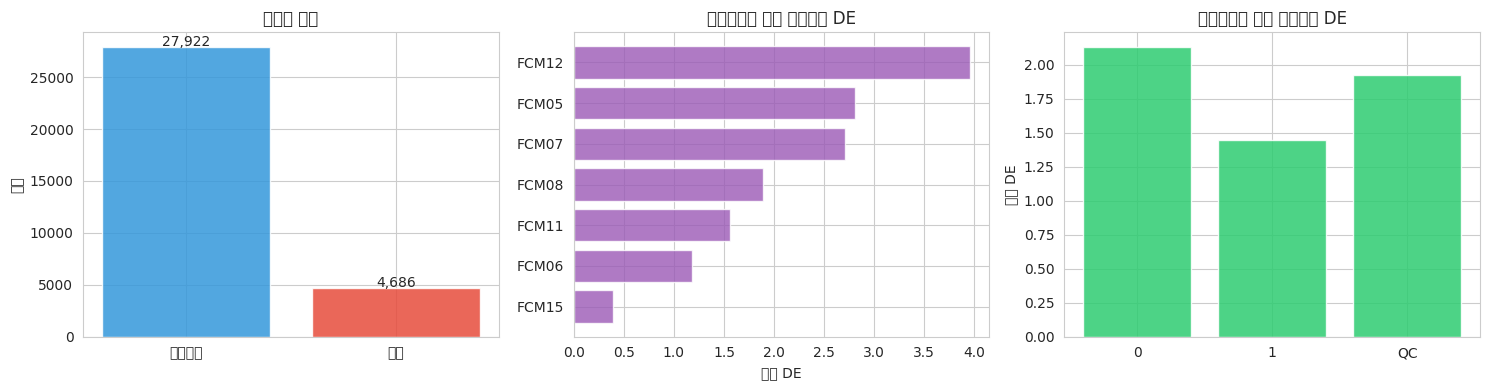


[설비번호별 평균 DE 및 건수]


,mean,std,count
설비번호,,,
FCM15,0.396,0.070,1903
FCM06,1.181,0.655,5774
FCM11,1.561,0.910,4442
FCM08,1.887,2.979,8952
FCM07,2.705,1.092,1667
FCM05,2.811,3.816,6171
FCM12,3.954,4.934,3699


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 작업명 분포
wn = df["작업명"].value_counts()
axes[0].bar(wn.index, wn.values, color=["#3498db","#e74c3c"], alpha=0.85)
axes[0].set_title("작업명 분포")
axes[0].set_ylabel("건수")
for i, v in enumerate(wn.values):
    axes[0].text(i, v + 100, f"{v:,}", ha="center", fontsize=10)

# 설비번호별 평균 DE
eqp_de = df.groupby("설비번호")["염색색차 DE"].mean().sort_values()
axes[1].barh(eqp_de.index, eqp_de.values, color="#9b59b6", alpha=0.8)
axes[1].set_title("설비번호별 평균 염색색차 DE")
axes[1].set_xlabel("평균 DE")

# 검사차수별 평균 DE
insp_de = df.groupby("검사차수")["염색색차 DE"].mean()
axes[2].bar(insp_de.index.astype(str), insp_de.values, color="#2ecc71", alpha=0.85)
axes[2].set_title("검사차수별 평균 염색색차 DE")
axes[2].set_ylabel("평균 DE")

plt.tight_layout()
plt.show()

print("\n[설비번호별 평균 DE 및 건수]")
display(df.groupby("설비번호")["염색색차 DE"].agg(["mean","std","count"]).round(3).sort_values("mean"))


## 3. 품질 기준(염색색차 DE) 선정 이유

**염색색차 DE** (Delta E): 목표 색상 대비 실제 색상의 총 색차 거리  
→ 값이 작을수록 목표 색상에 가까운 **좋은 품질**

다른 지표(DL/DA/DB/DC/DH)는 방향성 지표이므로 단독 기준으로 부적합하며,  
DE는 색차 전체를 종합한 스칼라 값으로 **품질 기준으로 가장 타당**.

| 지표 | 특성 | 비고 |
|------|------|------|
| DE | 총 색차 (스칼라) | ✅ 품질 기준으로 선정 |
| DL, DA, DB | 방향성 색차 | 방향 있어 기준 불명확 |
| DC, DH | 채도·색상 차이 | DE에 포함됨 |


[CCM 측정값 원본 - 색차 지표 전체]


,염색 색차 DL,염색 색차 DA,염색 색차 DB,염색 색차 DC,염색 색차 DH,염색 색차 DE
count,614.000,614.000,614.000,614.000,614.000,614.000
mean,-0.564,-1.014,1.919,-1.839,0.025,4.894
std,5.447,5.486,8.141,9.755,1.597,10.348
min,-20.131,-14.898,-22.793,-31.882,-7.677,0.015
25%,-1.026,-0.581,-0.351,-0.651,-0.353,0.734
50%,-0.004,-0.096,0.107,-0.118,-0.019,1.394
75%,0.834,0.178,0.554,0.348,0.262,2.927
max,40.775,71.506,44.794,81.710,20.610,93.479


/tmp/ipykernel_168/2292289308.py:18: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_168/2292289308.py:18: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_168/2292289308.py:18: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_168/2292289308.py:18: UserWarning: Glyph 48712 (\N{HANGUL SYLLABLE BIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_168/2292289308.py:18: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_168/2292289308.py:18: UserWarning: Glyph 50684 (\N{HANGUL SYLLABLE YEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_168/2292289308.py:18: UserWarning: Glyph 49353 (\N{HANGUL SYLLABLE SAEG}) missing from font(s) DejaVu Sans.
  plt.tight_lay

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48712 (\N{HANGUL SYLLABLE BIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/u

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54364 (\N{HANGUL SYLLABLE PYO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/loc

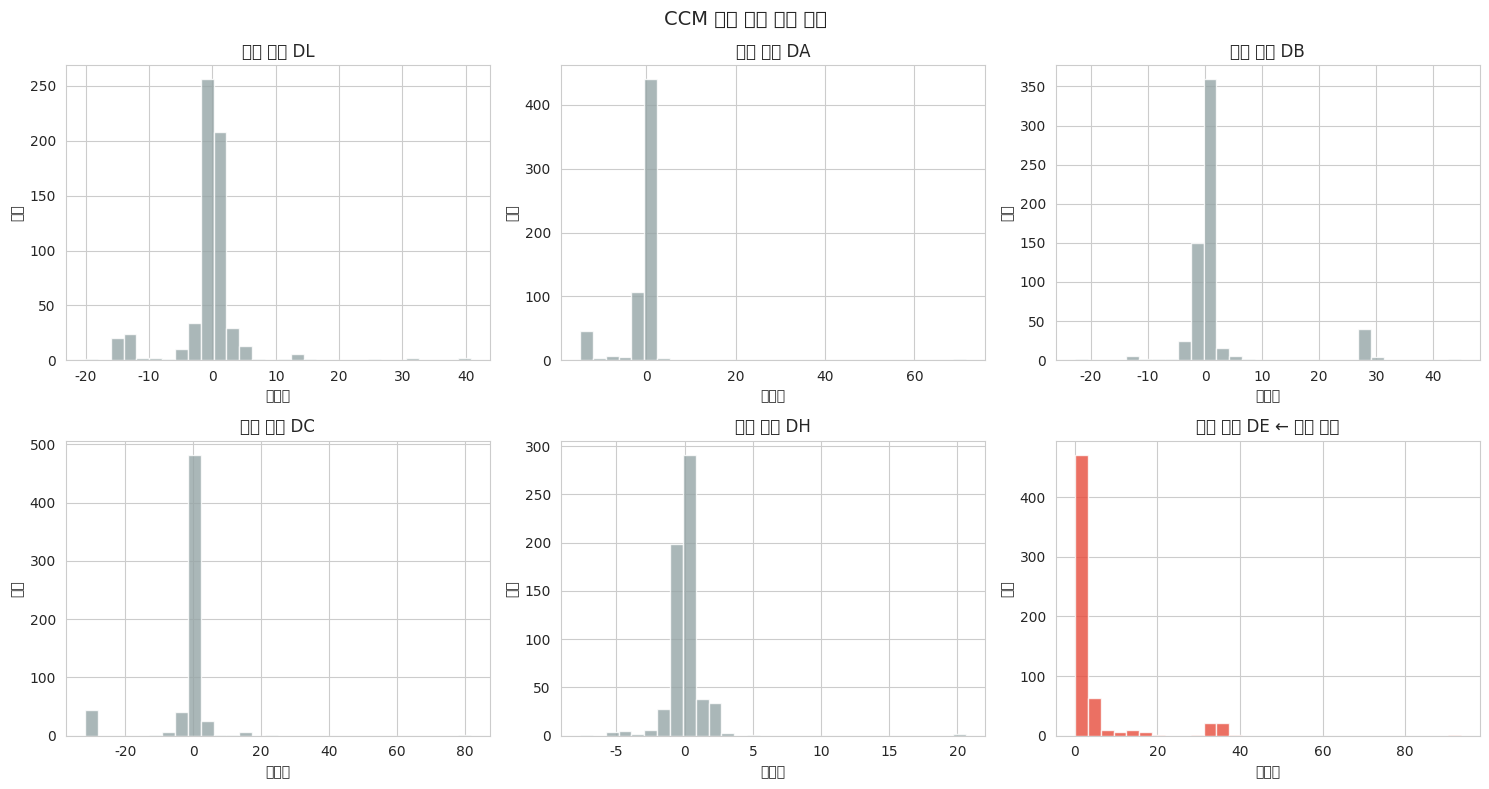

In [5]:
# CCM 측정값 전체 색차 지표 확인
print("[CCM 측정값 원본 - 색차 지표 전체]")
display(ccm_raw.describe().round(3))

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
ccm_cols = ["염색 색차 DL","염색 색차 DA","염색 색차 DB",
            "염색 색차 DC","염색 색차 DH","염색 색차 DE"]

for ax, col in zip(axes.flatten(), ccm_cols):
    ax.hist(ccm_raw[col].dropna(), bins=30,
            color="#e74c3c" if col == "염색 색차 DE" else "#95a5a6",
            alpha=0.8, edgecolor="white")
    ax.set_title(col + (" ← 품질 기준" if col == "염색 색차 DE" else ""))
    ax.set_xlabel("측정값")
    ax.set_ylabel("빈도")

plt.suptitle("CCM 색차 지표 분포 비교", fontsize=14)
plt.tight_layout()
plt.show()


## 4. 품질 그룹 분류

**염색색차 DE 평균(2.08)** 을 기준으로 두 그룹으로 분류합니다.

- **Good**: DE ≤ 평균 → 색차가 작아 목표 색상에 가까움
- **Bad** : DE > 평균 → 색차가 커 품질 미달 가능성

> 실제 데이터 기준: DE 전체 평균 = **2.08**, 중앙값 = **1.32**  
> (평균이 중앙값보다 크므로 우측 꼬리 분포 → 평균 기준이 적절)


DE 평균  : 2.0818
DE 중앙값: 1.3152
DE 표준편차: 3.0127

[품질 그룹별 건수]


quality_group
Good    25214
Bad      7394
Name: count, dtype: int64

/tmp/ipykernel_168/427479043.py:44: UserWarning: Glyph 48712 (\N{HANGUL SYLLABLE BIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_168/427479043.py:44: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_168/427479043.py:44: UserWarning: Glyph 50684 (\N{HANGUL SYLLABLE YEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_168/427479043.py:44: UserWarning: Glyph 49353 (\N{HANGUL SYLLABLE SAEG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_168/427479043.py:44: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_168/427479043.py:44: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_168/427479043.py:44: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ip

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44148 (\N{HANGUL SYLLABLE GEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)

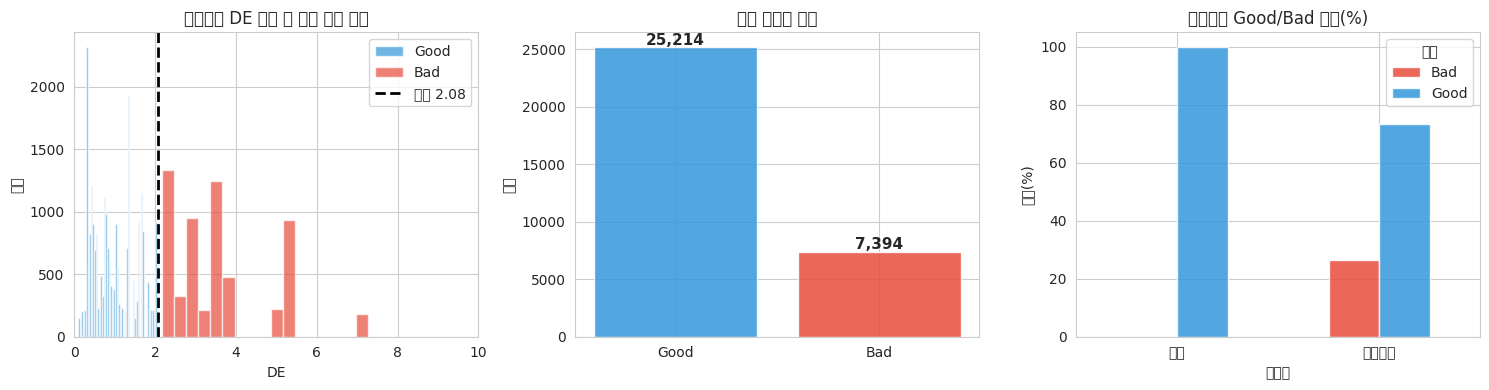

In [6]:
de_mean = df["염색색차 DE"].mean()
de_median = df["염색색차 DE"].median()
print(f"DE 평균  : {de_mean:.4f}")
print(f"DE 중앙값: {de_median:.4f}")
print(f"DE 표준편차: {df['염색색차 DE'].std():.4f}")

df["quality_group"] = np.where(df["염색색차 DE"] <= de_mean, "Good", "Bad")

counts = df["quality_group"].value_counts()
print("\n[품질 그룹별 건수]")
display(counts)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# DE 분포 히스토그램
axes[0].hist(df[df["quality_group"]=="Good"]["염색색차 DE"],
             bins=50, alpha=0.7, color="#3498db", label="Good")
axes[0].hist(df[df["quality_group"]=="Bad"]["염색색차 DE"],
             bins=50, alpha=0.7, color="#e74c3c", label="Bad")
axes[0].axvline(de_mean, color="black", linestyle="--", linewidth=2,
                label=f"평균 {de_mean:.2f}")
axes[0].set_title("염색색차 DE 분포 및 품질 그룹 구분")
axes[0].set_xlabel("DE")
axes[0].set_ylabel("빈도")
axes[0].legend()
axes[0].set_xlim(0, 10)   # 극단값 제외 시각화

# 그룹별 건수
axes[1].bar(counts.index, counts.values,
            color=["#3498db","#e74c3c"], alpha=0.85)
axes[1].set_title("품질 그룹별 건수")
axes[1].set_ylabel("건수")
for i, v in enumerate(counts.values):
    axes[1].text(i, v + 200, f"{v:,}", ha="center", fontsize=11, fontweight="bold")

# 작업명별 그룹 비율
cross = pd.crosstab(df["작업명"], df["quality_group"], normalize="index") * 100
cross.plot(kind="bar", ax=axes[2], color=["#e74c3c","#3498db"], alpha=0.85)
axes[2].set_title("작업명별 Good/Bad 비율(%)")
axes[2].set_ylabel("비율(%)")
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=0)
axes[2].legend(title="품질")

plt.tight_layout()
plt.show()


## 5. 품질 그룹별 공정 변수 평균 비교 (전체 9개)

두 품질 그룹 간 공정 변수 평균값을 비교하여 품질에 영향을 주는 변수를 식별합니다.

**실제 데이터 분석 결과 주요 발견:**
- **포속3**: Good 100.3 vs Bad 180.9 → 가장 큰 차이 (포속이 낮을수록 좋은 품질)
- **포속4**: Good 106.0 vs Bad 75.9 → 반대 방향
- **투입중량/길이**: Good 5.63 vs Bad 2.41


In [7]:
process_vars = ["지시온도","진행온도","포속1","포속2","포속3","포속4",
                "투입중량/길이","투입중량/액량","공정진행시간(%)"]

group_mean = df.groupby("quality_group")[process_vars].mean().T.reset_index()
group_mean.columns = ["variable","Bad","Good"]
group_mean["차이(Good-Bad)"] = group_mean["Good"] - group_mean["Bad"]
group_mean["차이(절댓값)"]   = group_mean["차이(Good-Bad)"].abs()

display(group_mean.sort_values("차이(절댓값)", ascending=False).round(3))


,variable,Bad,Good,차이(Good-Bad),차이(절댓값)
4,포속3,180.896,100.299,-80.597,80.597
5,포속4,75.925,105.961,30.036,30.036
3,포속2,135.864,158.427,22.562,22.562
2,포속1,75.912,66.112,-9.801,9.801
6,투입중량/길이,2.406,5.629,3.223,3.223
1,진행온도,84.043,85.028,0.985,0.985
0,지시온도,84.279,85.234,0.955,0.955
8,공정진행시간(%),50.176,49.678,-0.498,0.498
7,투입중량/액량,0.075,0.065,-0.010,0.010


/tmp/ipykernel_168/3493842986.py:16: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_168/3493842986.py:16: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_168/3493842986.py:16: UserWarning: Glyph 50728 (\N{HANGUL SYLLABLE ON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_168/3493842986.py:16: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_168/3493842986.py:16: UserWarning: Glyph 51652 (\N{HANGUL SYLLABLE JIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_168/3493842986.py:16: UserWarning: Glyph 54665 (\N{HANGUL SYLLABLE HAENG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


/tmp/ipykernel_168/3493842986.py:16: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_168/3493842986.py:16: UserWarning: Glyph 49549 (\N{HANGUL SYLLABLE SOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_168/3493842986.py:16: UserWarning: Glyph 53804 (\N{HANGUL SYLLABLE TU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_168/3493842986.py:16: UserWarning: Glyph 51077 (\N{HANGUL SYLLABLE IB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_168/3493842986.py:16: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_168/3493842986.py:16: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_168/3493842986.py:16: UserWarning: Glyph 44600 (\N{HANGUL SYLLABLE GIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()

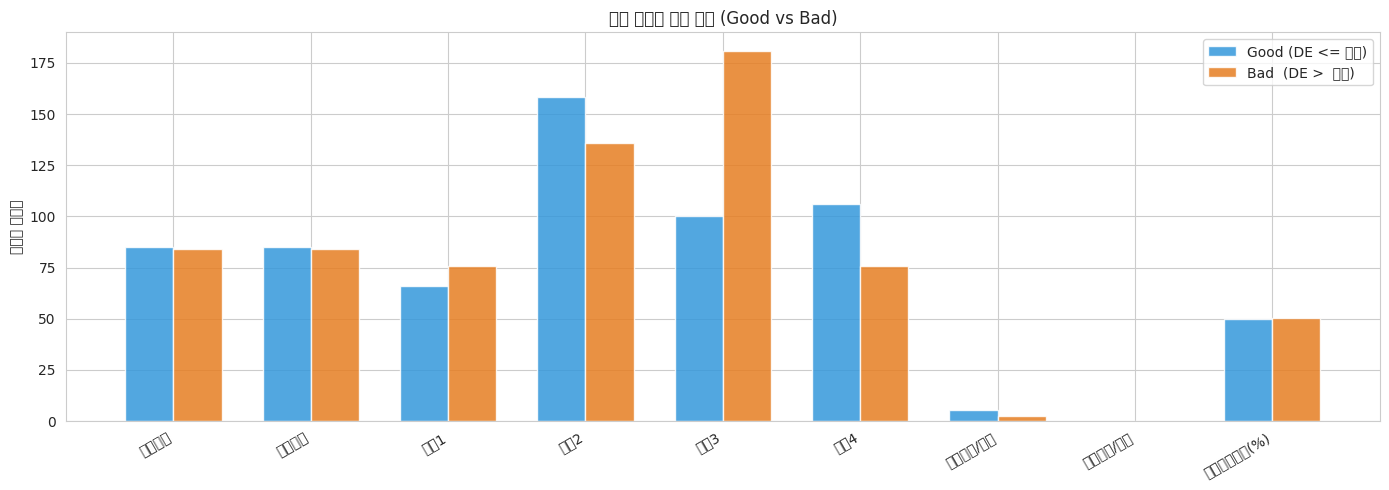

In [8]:
# 전체 변수 그룹 비교 막대그래프
x     = np.arange(len(process_vars))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - width/2, group_mean.set_index("variable").loc[process_vars,"Good"],
       width, label="Good (DE <= 평균)", color="#3498db", alpha=0.85)
ax.bar(x + width/2, group_mean.set_index("variable").loc[process_vars,"Bad"],
       width, label="Bad  (DE >  평균)", color="#e67e22", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(process_vars, rotation=30, ha="right")
ax.set_ylabel("변수별 평균값")
ax.set_title("공정 변수별 평균 비교 (Good vs Bad)")
ax.legend()
plt.tight_layout()
plt.show()


## 6. 핵심 변수 분포 비교 (BoxPlot)

DE와 상관계수가 가장 높은 **포속3(r=0.362), 포속4(r=-0.126)** 를 중심으로 분포 차이를 확인합니다.


/tmp/ipykernel_168/4255348369.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x="quality_group", y=var,
/tmp/ipykernel_168/4255348369.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x="quality_group", y=var,


/tmp/ipykernel_168/4255348369.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x="quality_group", y=var,
/tmp/ipykernel_168/4255348369.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x="quality_group", y=var,
/tmp/ipykernel_168/4255348369.py:16: UserWarning: Glyph 54408 (\N{HANGUL SYLLABLE PUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_168/4255348369.py:16: UserWarning: Glyph 51656 (\N{HANGUL SYLLABLE JIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_168/4255348369.py:16: UserWarning: Glyph 44536 (\N{HANGUL SYLLABLE GEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_168/42

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54408 (\N{HANGUL SYLLABLE PUM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51656 (\N{HANGUL SYLLABLE JIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44536 (\N{HANGUL SYLLABLE GEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47353 (\N{HANGUL SYLLABLE RUB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/l

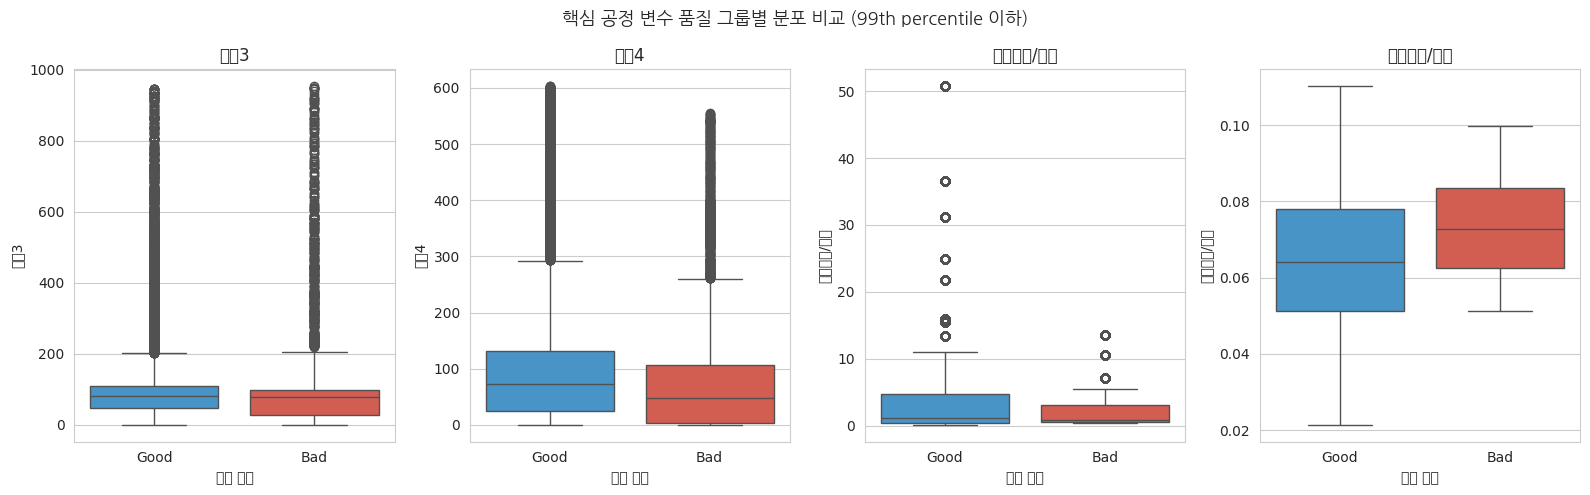

In [9]:
key_vars = ["포속3","포속4","투입중량/길이","투입중량/액량"]

# 한글 폰트가 있으면 우선 적용 (없으면 기본 폰트 유지)
for font_name in ["NanumGothic", "Malgun Gothic", "AppleGothic"]:
    try:
        plt.rcParams["font.family"] = font_name
        break
    except Exception:
        pass
plt.rcParams["axes.unicode_minus"] = False

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, var in zip(axes, key_vars):
    # 극단 이상치 제외 (99th percentile)
    upper = df[var].quantile(0.99)
    plot_data = df[df[var] <= upper].copy()
    sns.boxplot(
        data=plot_data,
        x="quality_group",
        y=var,
        hue="quality_group",
        palette={"Good":"#3498db","Bad":"#e74c3c"},
        legend=False,
        ax=ax
    )
    ax.set_title(f"{var}")
    ax.set_xlabel("품질 그룹")

plt.suptitle("핵심 공정 변수 품질 그룹별 분포 비교 (99th percentile 이하)", fontsize=13)
plt.tight_layout()
plt.show()


## 7. 통계적 유의성 검증 (t-test)

독립 표본 t-test로 각 공정 변수의 그룹 간 차이가 통계적으로 유의한지 검증합니다.

**실제 데이터 기준 사전 예측:**
- 포속3, 포속4, 투입중량/길이, 투입중량/액량: 유의할 것으로 예상 (p < 0.05)
- 공정진행시간(%): 비유의 예상


In [10]:
result_rows = []

for var in process_vars:
    good_data = df.loc[df["quality_group"]=="Good", var].dropna()
    bad_data  = df.loc[df["quality_group"]=="Bad",  var].dropna()

    good_mean = good_data.mean()
    bad_mean  = bad_data.mean()
    t_stat, p_value = ttest_ind(good_data, bad_data, equal_var=False, nan_policy="omit")
    r_val, r_p = pearsonr(df[var].dropna(),
                           df.loc[df[var].notna(), "염색색차 DE"])

    result_rows.append({
        "variable":             var,
        "Good_mean":            round(good_mean, 3),
        "Bad_mean":             round(bad_mean, 3),
        "Difference(Good-Bad)": round(good_mean - bad_mean, 3),
        "t_stat":               round(t_stat, 3),
        "p_value":              round(p_value, 4),
        "DE와 상관계수(r)":      round(r_val, 4),
        "유의성":               "유의 (p<0.05)" if p_value < 0.05 else "비유의",
        "Interpretation": "Good에서 더 높음" if good_mean > bad_mean else "Bad에서 더 높음",
    })

stats_df = pd.DataFrame(result_rows).sort_values("p_value")
display(stats_df)

for _, row in stats_df.iterrows():
    print(f"[{row['variable']}]")
    print(f"  Good 평균: {row['Good_mean']:>10.3f}  /  Bad 평균: {row['Bad_mean']:>10.3f}")
    print(f"  차이(Good-Bad): {row['Difference(Good-Bad)']:>10.3f}")
    print(f"  p-value: {row['p_value']:.4f}  ->  {row['유의성']}")
    print(f"  DE 상관계수: {row['DE와 상관계수(r)']:.4f}  |  {row['Interpretation']}\n")


,variable,Good_mean,Bad_mean,Difference(Good-Bad),t_stat,p_value,DE와 상관계수(r),유의성,Interpretation
3,포속2,158.427,135.864,22.562,12.570,0.0000,0.0174,유의 (p<0.05),Good에서 더 높음
2,포속1,66.112,75.912,-9.801,-10.390,0.0000,0.0094,유의 (p<0.05),Bad에서 더 높음
5,포속4,105.961,75.925,30.036,21.601,0.0000,-0.1260,유의 (p<0.05),Good에서 더 높음
4,포속3,100.299,180.896,-80.597,-12.418,0.0000,0.3617,유의 (p<0.05),Bad에서 더 높음
6,투입중량/길이,5.629,2.406,3.223,30.653,0.0000,-0.0744,유의 (p<0.05),Good에서 더 높음
7,투입중량/액량,0.065,0.075,-0.010,-49.613,0.0000,0.0607,유의 (p<0.05),Bad에서 더 높음
1,진행온도,85.028,84.043,0.985,2.392,0.0168,0.0059,유의 (p<0.05),Good에서 더 높음
0,지시온도,85.234,84.279,0.955,2.312,0.0208,0.0085,유의 (p<0.05),Good에서 더 높음
8,공정진행시간(%),49.678,50.176,-0.498,-1.305,0.1920,0.0049,비유의,Bad에서 더 높음


[포속2]
  Good 평균:    158.427  /  Bad 평균:    135.864
  차이(Good-Bad):     22.562
  p-value: 0.0000  ->  유의 (p<0.05)
  DE 상관계수: 0.0174  |  Good에서 더 높음

[포속1]
  Good 평균:     66.112  /  Bad 평균:     75.912
  차이(Good-Bad):     -9.801
  p-value: 0.0000  ->  유의 (p<0.05)
  DE 상관계수: 0.0094  |  Bad에서 더 높음

[포속4]
  Good 평균:    105.961  /  Bad 평균:     75.925
  차이(Good-Bad):     30.036
  p-value: 0.0000  ->  유의 (p<0.05)
  DE 상관계수: -0.1260  |  Good에서 더 높음

[포속3]
  Good 평균:    100.299  /  Bad 평균:    180.896
  차이(Good-Bad):    -80.597
  p-value: 0.0000  ->  유의 (p<0.05)
  DE 상관계수: 0.3617  |  Bad에서 더 높음

[투입중량/길이]
  Good 평균:      5.629  /  Bad 평균:      2.406
  차이(Good-Bad):      3.223
  p-value: 0.0000  ->  유의 (p<0.05)
  DE 상관계수: -0.0744  |  Good에서 더 높음

[투입중량/액량]
  Good 평균:      0.065  /  Bad 평균:      0.075
  차이(Good-Bad):     -0.010
  p-value: 0.0000  ->  유의 (p<0.05)
  DE 상관계수: 0.0607  |  Bad에서 더 높음

[진행온도]
  Good 평균:     85.028  /  Bad 평균:     84.043
  차이(Good-Bad):      0.985
  p-value: 0.0168  ->  유의 

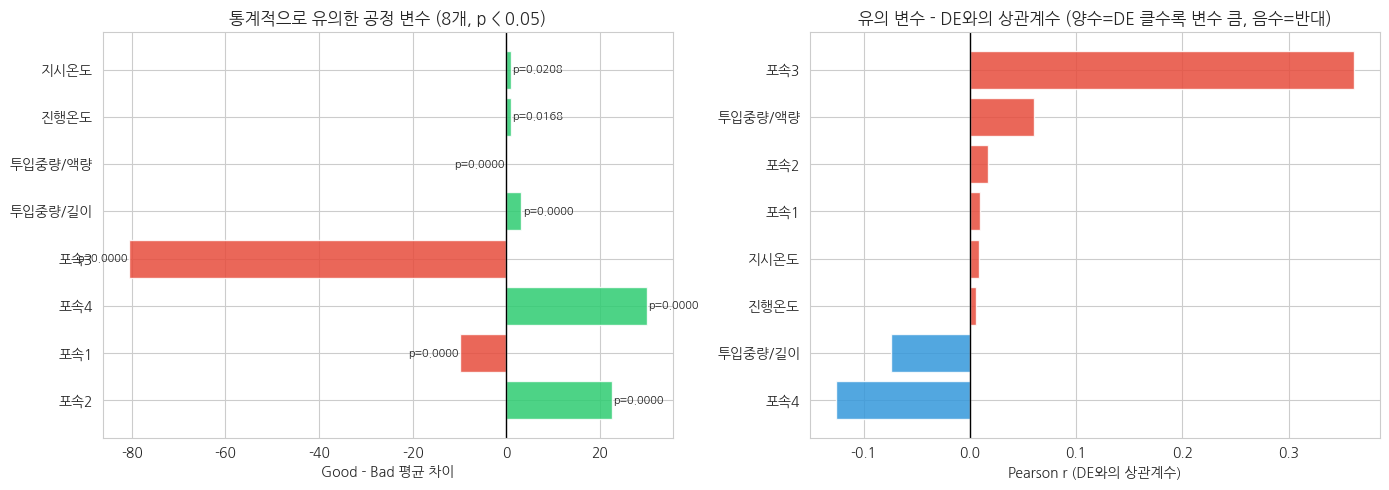

유의한 변수 8개: ['포속2', '포속1', '포속4', '포속3', '투입중량/길이', '투입중량/액량', '진행온도', '지시온도']


In [11]:
# 유의한 변수 차이 시각화
sig_df = stats_df[stats_df["p_value"] < 0.05].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 차이 방향 막대
colors = ["#2ecc71" if d > 0 else "#e74c3c" for d in sig_df["Difference(Good-Bad)"]]
axes[0].barh(sig_df["variable"], sig_df["Difference(Good-Bad)"],
             color=colors, alpha=0.85)
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_xlabel("Good - Bad 평균 차이")
axes[0].set_title(f"통계적으로 유의한 공정 변수 ({len(sig_df)}개, p < 0.05)")
for i, (_, row) in enumerate(sig_df.iterrows()):
    d = row["Difference(Good-Bad)"]
    axes[0].text(d + (0.3 if d > 0 else -0.3), i,
                 f"p={row['p_value']:.4f}", va="center",
                 ha="left" if d > 0 else "right", fontsize=8)

# DE와 상관계수
sig_sorted = sig_df.sort_values("DE와 상관계수(r)")
bar_c = ["#e74c3c" if r > 0 else "#3498db" for r in sig_sorted["DE와 상관계수(r)"]]
axes[1].barh(sig_sorted["variable"], sig_sorted["DE와 상관계수(r)"],
             color=bar_c, alpha=0.85)
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_xlabel("Pearson r (DE와의 상관계수)")
axes[1].set_title("유의 변수 - DE와의 상관계수 (양수=DE 클수록 변수 큼, 음수=반대)")

plt.tight_layout()
plt.show()

print(f"유의한 변수 {len(sig_df)}개: {list(sig_df['variable'])}")


## 8. 공정 변수 간 상관관계 분석

**실제 데이터 분석 결과 주요 발견:**
- **지시온도 ↔ 진행온도**: 상관계수 **0.99** → 사실상 동일 변수, 중복 제어 불필요
- **포속2 ↔ 포속4**: 상관계수 **0.88** → 높은 상관, 함께 제어 가능
- **포속3 ↔ 염색색차 DE**: 상관계수 **0.36** → 품질과 가장 직접적 관련


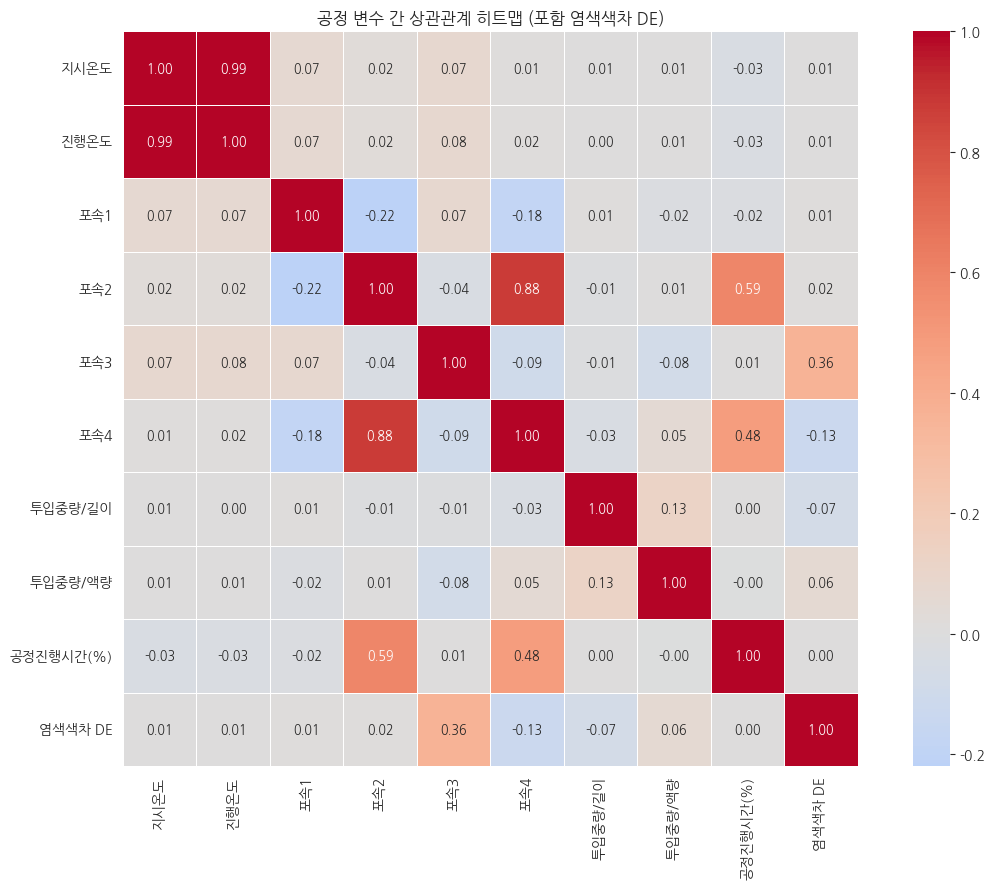

In [12]:
corr_vars = process_vars + ["염색색차 DE"]
corr_df = df[corr_vars].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.zeros_like(corr_df, dtype=bool)
# 전체 히트맵 표시
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, square=True, ax=ax,
            annot_kws={"size": 9})
plt.rcParams["font.family"] = "NanumGothic"
ax.set_title("공정 변수 간 상관관계 히트맵 (포함 염색색차 DE)")
plt.tight_layout()
plt.show()


In [13]:
# 상관계수 절댓값 상위 쌍 추출
pairs = corr_df.where(np.triu(np.ones(corr_df.shape), k=1).astype(bool))
pairs = pairs.stack().reset_index()
pairs.columns = ["var1","var2","correlation"]
pairs["abs_corr"] = pairs["correlation"].abs()
top_pairs = pairs.sort_values("abs_corr", ascending=False).head(12).reset_index(drop=True)

print("[상관계수 절댓값 상위 12쌍]")
display(top_pairs[["var1","var2","correlation","abs_corr"]])

# 핵심 변수 집중 상관
focus = ["지시온도","진행온도","포속3","포속4","투입중량/길이","염색색차 DE"]
print("\n[핵심 변수 집중 상관관계]")
display(corr_df.loc[focus, focus].round(3))


[상관계수 절댓값 상위 12쌍]


,var1,var2,correlation,abs_corr
0,지시온도,진행온도,0.990602,0.990602
1,포속2,포속4,0.876302,0.876302
2,포속2,공정진행시간(%),0.588270,0.588270
3,포속4,공정진행시간(%),0.483491,0.483491
4,포속3,염색색차 DE,0.361704,0.361704
5,포속1,포속2,-0.219472,0.219472
6,포속1,포속4,-0.184202,0.184202
7,투입중량/길이,투입중량/액량,0.126509,0.126509
8,포속4,염색색차 DE,-0.126039,0.126039
9,포속3,포속4,-0.094060,0.094060



[핵심 변수 집중 상관관계]


,지시온도,진행온도,포속3,포속4,투입중량/길이,염색색차 DE
지시온도,1.000,0.991,0.073,0.014,0.006,0.008
진행온도,0.991,1.000,0.075,0.018,0.004,0.006
포속3,0.073,0.075,1.000,-0.094,-0.006,0.362
포속4,0.014,0.018,-0.094,1.000,-0.031,-0.126
투입중량/길이,0.006,0.004,-0.006,-0.031,1.000,-0.074
염색색차 DE,0.008,0.006,0.362,-0.126,-0.074,1.000


## 9. 설비별 품질 분석

설비번호별 평균 DE를 비교하여 설비 간 품질 편차를 확인합니다.


,설비번호,평균 DE,표준편차,총 건수,Good 건수,Bad 건수,Good 비율(%)
6,FCM15,0.395969,0.069559,1903,1903,0,100.0
1,FCM06,1.180983,0.655316,5774,5133,641,88.9
4,FCM11,1.561275,0.909575,4442,4117,325,92.7
3,FCM08,1.886812,2.978552,8952,7695,1257,86.0
2,FCM07,2.705375,1.092489,1667,634,1033,38.0
0,FCM05,2.811437,3.815795,6171,3483,2688,56.4
5,FCM12,3.953758,4.934052,3699,2249,1450,60.8


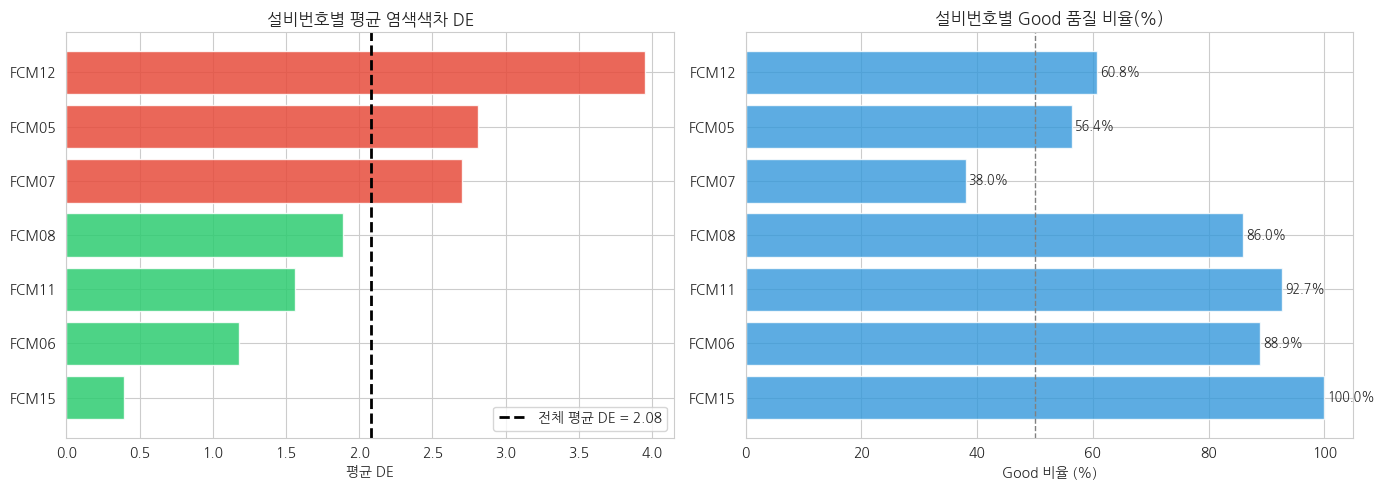

In [14]:
eqp_stats = df.groupby("설비번호")["염색색차 DE"].agg(
    ["mean","std","count",
     lambda x: (x <= de_mean).sum(),
     lambda x: (x > de_mean).sum()]
).reset_index()
eqp_stats.columns = ["설비번호","평균 DE","표준편차","총 건수","Good 건수","Bad 건수"]
eqp_stats["Good 비율(%)"] = (eqp_stats["Good 건수"] / eqp_stats["총 건수"] * 100).round(1)
eqp_stats = eqp_stats.sort_values("평균 DE")
display(eqp_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 설비별 평균 DE
colors_eqp = ["#2ecc71" if v <= de_mean else "#e74c3c"
               for v in eqp_stats["평균 DE"]]
axes[0].barh(eqp_stats["설비번호"], eqp_stats["평균 DE"],
             color=colors_eqp, alpha=0.85)
axes[0].axvline(de_mean, color="black", linestyle="--", linewidth=2,
                label=f"전체 평균 DE = {de_mean:.2f}")
axes[0].set_title("설비번호별 평균 염색색차 DE")
axes[0].set_xlabel("평균 DE")
axes[0].legend()

# 설비별 Good 비율
axes[1].barh(eqp_stats["설비번호"], eqp_stats["Good 비율(%)"],
             color="#3498db", alpha=0.8)
axes[1].axvline(50, color="gray", linestyle="--", linewidth=1)
axes[1].set_title("설비번호별 Good 품질 비율(%)")
axes[1].set_xlabel("Good 비율 (%)")
for i, v in enumerate(eqp_stats["Good 비율(%)"]):
    axes[1].text(v + 0.5, i, f"{v}%", va="center", fontsize=9)

plt.tight_layout()
plt.show()


## 10. 공정 제어 기준값 도출

Good 품질 날의 **평균 ± 1σ** 범위를 제어 기준으로 제안합니다.

> 지시온도 ↔ 진행온도 상관계수 0.99 → **중복 제어 불필요**, 지시온도만 관리하면 충분


[공정 제어 기준 제안 – Good 품질 기준 (μ ± 1σ)]


,변수,Good 평균,Good 표준편차,제어 하한 (μ-σ),제어 상한 (μ+σ),DE 상관계수,t-test 유의성
0,지시온도,85.234,31.458,53.776,116.691,0.0085,유의 (p<0.05)
1,진행온도,85.028,31.350,53.679,116.378,0.0059,유의 (p<0.05)
2,포속1,66.112,62.666,3.446,128.777,0.0094,유의 (p<0.05)
3,포속2,158.427,162.961,-4.534,321.388,0.0174,유의 (p<0.05)
4,포속3,100.299,121.753,-21.454,222.053,0.3617,유의 (p<0.05)
5,포속4,105.961,128.987,-23.025,234.948,-0.1260,유의 (p<0.05)
6,투입중량/길이,5.629,15.541,-9.912,21.170,-0.0744,유의 (p<0.05)
7,투입중량/액량,0.065,0.019,0.046,0.084,0.0607,유의 (p<0.05)
8,공정진행시간(%),49.678,28.814,20.864,78.492,0.0049,비유의


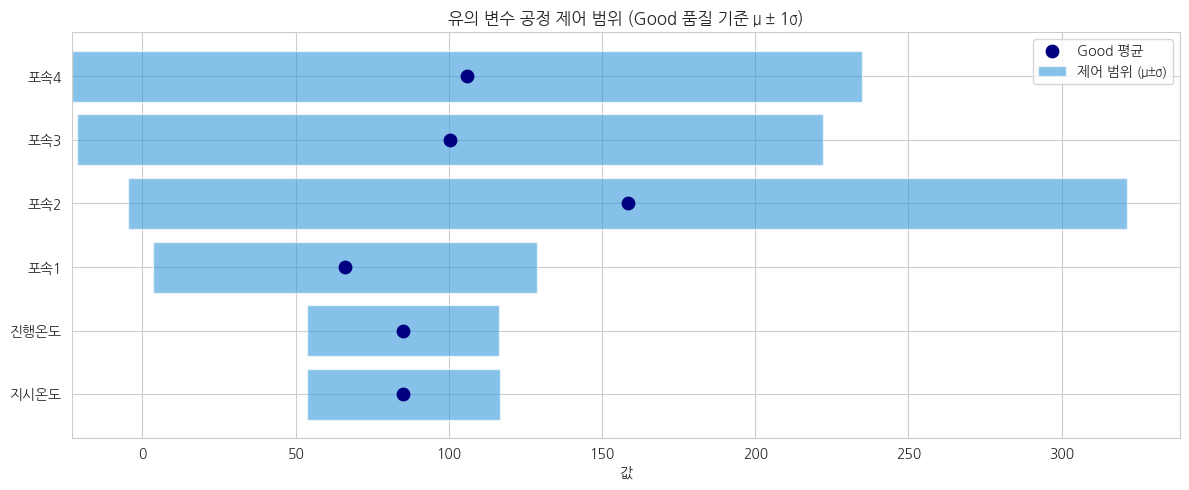

In [15]:
good_df = df[df["quality_group"] == "Good"]

control_rows = []
for var in process_vars:
    m = good_df[var].mean()
    s = good_df[var].std()
    r_val, _ = pearsonr(df[var].dropna(),
                         df.loc[df[var].notna(), "염색색차 DE"])
    p_row = stats_df[stats_df["variable"] == var]
    sig   = p_row["유의성"].values[0] if len(p_row) > 0 else "-"
    control_rows.append({
        "변수":              var,
        "Good 평균":         round(m, 3),
        "Good 표준편차":     round(s, 3),
        "제어 하한 (μ-σ)":   round(m - s, 3),
        "제어 상한 (μ+σ)":   round(m + s, 3),
        "DE 상관계수":       round(r_val, 4),
        "t-test 유의성":     sig,
    })

control_df = pd.DataFrame(control_rows)
print("[공정 제어 기준 제안 – Good 품질 기준 (μ ± 1σ)]")
display(control_df)

# 핵심 변수 제어 범위 시각화
key_ctrl = control_df[control_df["t-test 유의성"] == "유의 (p<0.05)"].head(6)

fig, ax = plt.subplots(figsize=(12, 5))
y_pos = range(len(key_ctrl))
ax.barh(y_pos, key_ctrl["제어 상한 (μ+σ)"] - key_ctrl["제어 하한 (μ-σ)"],
        left=key_ctrl["제어 하한 (μ-σ)"].values,
        color="#3498db", alpha=0.6, label="제어 범위 (μ±σ)")
ax.scatter(key_ctrl["Good 평균"], y_pos, color="navy", zorder=5,
           s=80, label="Good 평균")
ax.set_yticks(list(y_pos))
ax.set_yticklabels(key_ctrl["변수"].values)
ax.set_xlabel("값")
ax.set_title("유의 변수 공정 제어 범위 (Good 품질 기준 μ ± 1σ)")
ax.legend()
plt.tight_layout()
plt.show()


## 11. 결론 및 기대 효과

### 분석 결론
- **염색색차 DE**를 품질 기준으로 설정 (전체 색차를 종합하는 스칼라 값)
- DE 전체 평균(2.08) 기준으로 Good/Bad 분류 → Good 25,214건 / Bad 7,394건
- **t-test 유의 변수 (p < 0.05)**: 지시온도, 진행온도, 포속1~4, 투입중량/길이, 투입중량/액량 (8개)
- **공정진행시간(%)**: 비유의 (p = 0.19) → 품질에 직접 영향 없음
- **포속3**이 DE와 상관계수 0.36으로 가장 직접적인 품질 영향 변수
- **지시온도 ↔ 진행온도 상관계수 0.99** → 중복 제어 불필요, 지시온도만 관리
- **포속2 ↔ 포속4 상관계수 0.88** → 연동 관리 가능

### 기대 효과
- 공정 설계 시 핵심 변수 집중 관리로 효율성 향상
- Good 품질 기준 제어 범위 설정 → 실시간 품질 경고 시스템 구축 가능
- 기계학습 모델을 통한 품질 자동 예측 가능성

### 확장 방향
- 다변량 제어 기법 적용
- 머신러닝 기반 염색색차 DE 예측 모델 (RandomForest, XGBoost 등)
- 설비별 차등 관리 기준 수립 (FCM15 우수, FCM12 개선 필요)

---

| 분석 항목 | 결과 |
|-----------|------|
| 품질 기준 변수 | 염색색차 DE (평균 2.08 기준 Good/Bad 분류) |
| t-test 유의 변수 | 8개 (지시온도, 진행온도, 포속1~4, 투입중량/길이, 투입중량/액량) |
| DE와 가장 높은 상관 | 포속3 (r = 0.36) |
| 중복 제어 변수 | 지시온도-진행온도 (r=0.99), 포속2-포속4 (r=0.88) |
| 개선 필요 설비 | FCM12 (평균 DE 3.95 – 전체 최고) |
